In [23]:
from collections import defaultdict
from pathlib import Path
import csv
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_PATH = Path("results/benchmark_results.csv")
COMPARABLE_AVX2_HASHES = {"mask"}

df = pd.read_csv(RESULTS_PATH)

df["N"] = pd.to_numeric(df["N"], errors="coerce")
df["P"] = pd.to_numeric(df["P"], errors="coerce")
df["PARTITION_TIME"] = pd.to_numeric(df["PARTITION_TIME"], errors="coerce")
df["GLOBAL_TIME"] = pd.to_numeric(df["GLOBAL_TIME"], errors="coerce")

def filter_avx2_comparisons(frame):
    return frame[(frame["EXEC_TYPE"] != "avx2") | (frame["HASH"].isin(COMPARABLE_AVX2_HASHES))].copy()

df_compare = filter_avx2_comparisons(df)
excluded_rows = len(df) - len(df_compare)

exec_type_names = sorted(df["EXEC_TYPE"].dropna().unique())
exec_type_palette = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:gray",
    "tab:olive",
    "tab:cyan",
]
exec_type_colors = {
    exec_type: exec_type_palette[idx % len(exec_type_palette)]
    for idx, exec_type in enumerate(exec_type_names)
}

print(f"[Loaded {df.shape[0]} different runs from {RESULTS_PATH}]")
print("Distinct values for each column:")
print(f" EXEC_TYPE: {df['EXEC_TYPE'].unique()}")
print(f" HASH: {df['HASH'].unique()}")
print(f" N: {df['N'].unique()}")
print(f" P: {df['P'].unique()}")
print(f" Comparison rule: avx2 included only for HASH in {sorted(COMPARABLE_AVX2_HASHES)}")
print(f" Comparison dataset rows: {df_compare.shape[0]} (excluded {excluded_rows} unsupported avx2 rows)")
print(f" EXEC_TYPE colors: {exec_type_colors}")

[Loaded 120 different runs from results/benchmark_results.csv]
Distinct values for each column:
 EXEC_TYPE: ['plain_novec' 'plain_vec' 'avx2']
 HASH: ['mask']
 N: [10000000]
 P: [  64  256  512 2048]
 Comparison rule: avx2 included only for HASH in ['mask']
 Comparison dataset rows: 120 (excluded 0 unsupported avx2 rows)
 EXEC_TYPE colors: {'avx2': 'tab:blue', 'plain_novec': 'tab:orange', 'plain_vec': 'tab:green'}


# Checksum validation

In [24]:
summary_rows = []
df_grouped = df_compare.groupby(["N", "P", "HASH"])
valid_counter = 0
for (N, P, HASH), subdf in df_grouped:
    checksums = subdf["CHECKSUM"].unique()
    is_valid = len(checksums) == 1
    valid_counter += 1 if is_valid else 0

    summary_rows.append({
        "N": N,
        "P": P,
        "HASH": HASH,
        "valid": is_valid,
        "n_checksums": len(checksums),
        "checksums": " | ".join(map(str, checksums))
    })

if valid_counter == df_grouped.ngroups:
    print(f"[OK] All groups have a single unique checksum")
else:
    print(f"[FAIL] Only {valid_counter}/{df_grouped.ngroups} groups have a single unique checksum")

checksum_validation_df = pd.DataFrame(summary_rows)
checksum_validation_df


[OK] All groups have a single unique checksum


,N,P,HASH,valid,n_checksums,checksums
0,10000000,64,mask,True,1,180344641600089295815274362764746307001
1,10000000,256,mask,True,1,1314774605202903785416717757788193993593
2,10000000,512,mask,True,1,536831656504787356614739286363186079865
3,10000000,2048,mask,True,1,174751143964903068612950250125392416377


# Averaging

In [25]:
group_columns = ["N", "P", "HASH", "EXEC_TYPE", "CHECKSUM"]
avg_columns = [
    col for col in df_compare.columns
    if col not in group_columns and pd.api.types.is_numeric_dtype(df_compare[col])
]

# Collapse repeated runs and keep one averaged row for each stable configuration.
stable_avg_df = (
    df_compare.groupby(group_columns, as_index=False)
    .agg({col: "mean" for col in avg_columns})
    .rename(columns={col: f"AVG_{col}" for col in avg_columns})
    .sort_values(group_columns)
    .reset_index(drop=True)
)

stable_avg_df


,N,P,HASH,EXEC_TYPE,CHECKSUM,AVG_THROUGHPUT,AVG_PARTITION_TIME,AVG_GLOBAL_TIME
0,10000000,64,mask,avx2,180344641600089295815274362764746307001,1.353799e+09,0.014774,1.793045
1,10000000,64,mask,plain_novec,180344641600089295815274362764746307001,3.714083e+08,0.053850,1.992978
2,10000000,64,mask,plain_vec,180344641600089295815274362764746307001,8.827848e+08,0.022677,1.801920
3,10000000,256,mask,avx2,1314774605202903785416717757788193993593,1.355585e+09,0.014754,1.819578
4,10000000,256,mask,plain_novec,1314774605202903785416717757788193993593,3.714312e+08,0.053846,1.864724
5,10000000,256,mask,plain_vec,1314774605202903785416717757788193993593,8.928143e+08,0.022421,1.816094
6,10000000,512,mask,avx2,536831656504787356614739286363186079865,1.355778e+09,0.014752,1.789772
7,10000000,512,mask,plain_novec,536831656504787356614739286363186079865,3.717720e+08,0.053797,1.847646
8,10000000,512,mask,plain_vec,536831656504787356614739286363186079865,8.987274e+08,0.022267,1.806183
9,10000000,2048,mask,avx2,174751143964903068612950250125392416377,1.357695e+09,0.014731,1.809490


# Speedup

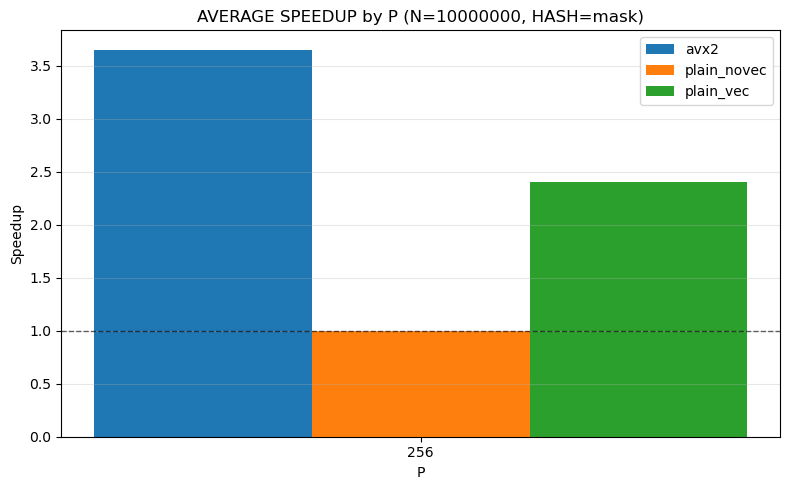

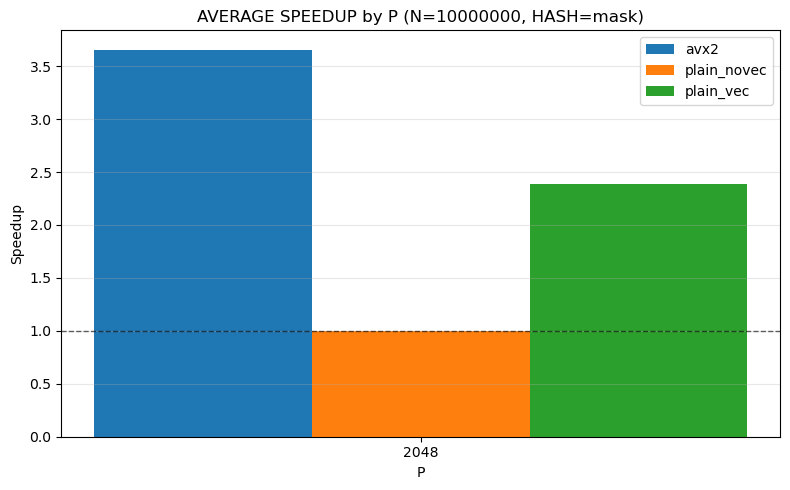

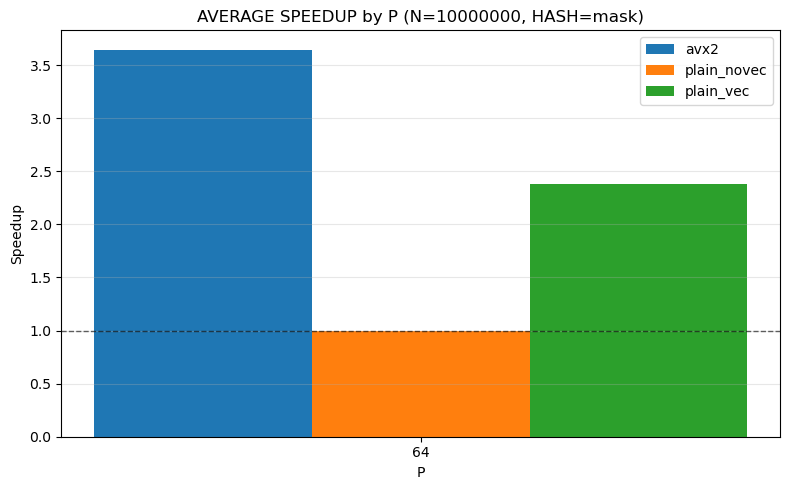

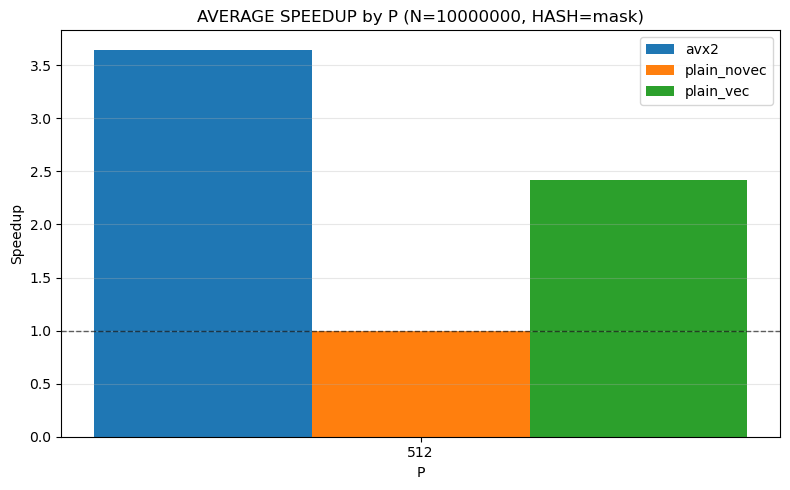

In [26]:
baseline_exec_type = "plain_novec"

# Use the averaged throughput of plain_novec as the reference for speedup.
baseline_df = (
    stable_avg_df[stable_avg_df["EXEC_TYPE"] == baseline_exec_type][
        ["N", "P", "HASH", "CHECKSUM", "AVG_THROUGHPUT"]
    ]
    .rename(columns={"AVG_THROUGHPUT": "BASELINE_AVG_THROUGHPUT"})
)

speedup_avg_df = stable_avg_df.merge(
    baseline_df,
    on=["N", "P", "HASH", "CHECKSUM"],
    how="left",
)
speedup_avg_df["SPEEDUP"] = (
    speedup_avg_df["AVG_THROUGHPUT"] / speedup_avg_df["BASELINE_AVG_THROUGHPUT"]
)

for (fixed_N, fixed_HASH, fixed_CHECKSUM), subdf in speedup_avg_df.groupby(["N", "HASH", "CHECKSUM"]):
    plot_df = subdf.sort_values(["P", "EXEC_TYPE"])
    if plot_df.empty:
        continue

    p_values = sorted(plot_df["P"].unique())
    exec_types = sorted(plot_df["EXEC_TYPE"].unique())
    p_to_x = {p: idx for idx, p in enumerate(p_values)}
    bar_width = 0.8 / max(len(exec_types), 1)
    center_offset = (len(exec_types) - 1) / 2

    plt.figure(figsize=(8, 5))
    for idx, exec_type in enumerate(exec_types):
        g = plot_df[plot_df["EXEC_TYPE"] == exec_type].sort_values("P")
        x_positions = [p_to_x[p] + (idx - center_offset) * bar_width for p in g["P"]]
        plt.bar(
            x_positions,
            g["SPEEDUP"],
            width=bar_width,
            color=exec_type_colors.get(exec_type, "tab:gray"),
            label=f"{exec_type}",
        )

    plt.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.6)
    plt.xticks(range(len(p_values)), p_values)
    plt.xlabel("P")
    plt.ylabel("Speedup")
    plt.title(f"AVERAGE SPEEDUP by P (N={fixed_N}, HASH={fixed_HASH})")
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Throughput

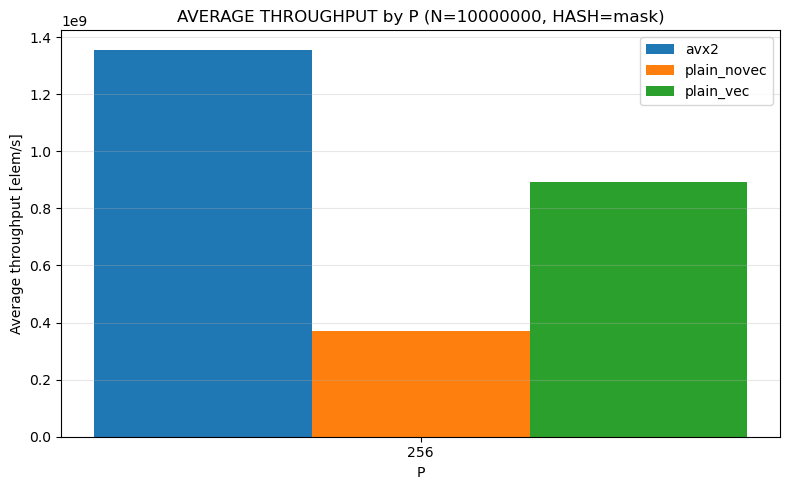

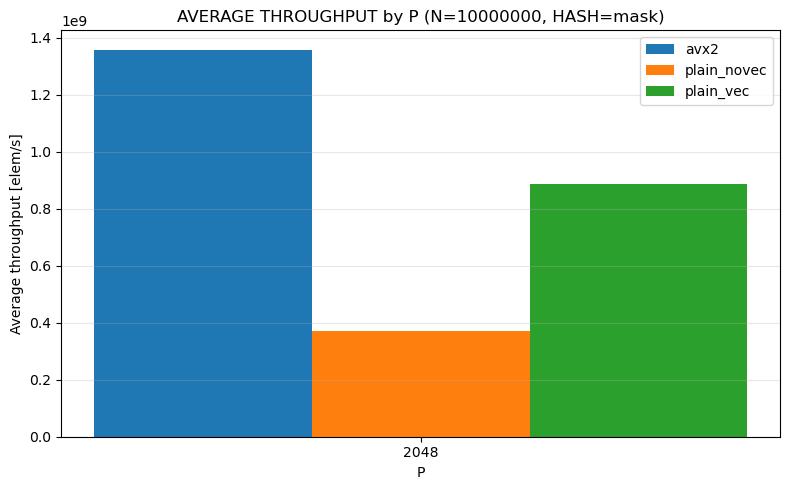

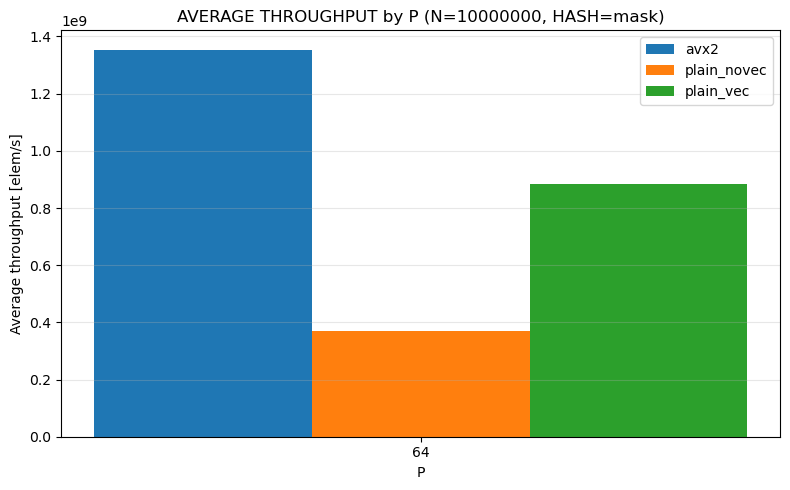

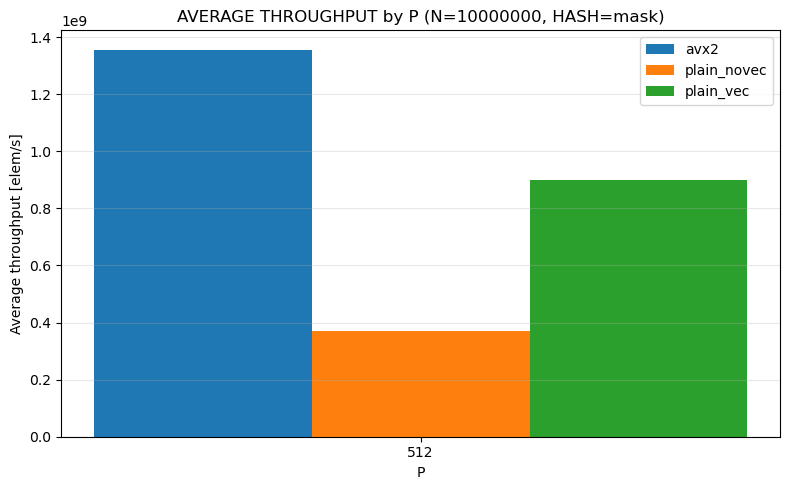

In [27]:
# Show the averaged throughput of each execution type for every P value.
for (fixed_N, fixed_HASH, fixed_CHECKSUM), subdf in stable_avg_df.groupby(["N", "HASH", "CHECKSUM"]):
    plot_df = subdf.sort_values(["P", "EXEC_TYPE"])
    p_values = sorted(plot_df["P"].unique())
    exec_types = sorted(plot_df["EXEC_TYPE"].unique())
    p_to_x = {p: idx for idx, p in enumerate(p_values)}
    bar_width = 0.8 / max(len(exec_types), 1)
    center_offset = (len(exec_types) - 1) / 2

    plt.figure(figsize=(8, 5))
    for idx, exec_type in enumerate(exec_types):
        g = plot_df[plot_df["EXEC_TYPE"] == exec_type].sort_values("P")
        x_positions = [p_to_x[p] + (idx - center_offset) * bar_width for p in g["P"]]
        plt.bar(
            x_positions,
            g["AVG_THROUGHPUT"],
            width=bar_width,
            color=exec_type_colors.get(exec_type, "tab:gray"),
            label=exec_type,
        )

    plt.xticks(range(len(p_values)), p_values)
    plt.xlabel("P")
    plt.ylabel("Average throughput [elem/s]")
    plt.title(f"AVERAGE THROUGHPUT by P (N={fixed_N}, HASH={fixed_HASH})")
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
